### Single Product Model — Target (Lower) Semi-Variance
This notebook examines an alternative to the **lower semi-variance (LSV)** objective used in
`single_product_lsv.ipynb`. Instead of penalizing downside deviations of revenue $W$ around its
own **sample mean** $\mathbb{E}[W]$, we penalize downside deviations around a **fixed target**
$m$ — the required farmer revenue. We call this the **Target Semi-Variance (TSV)**:

$$
\operatorname{TSV}(q) = \mathbb{E}\left[(m - W)_+^2\right], \qquad (x)_+ = \max(x, 0).
$$

This is the classical *lower partial moment of order 2* (LPM$_2$) relative to a target, and is
the natural risk measure behind the Sortino ratio. It differs from LSV in one important way:

| | LSV (original notebook) | TSV (this notebook) |
|---|---|---|
| Reference point | $\mathbb{E}[W]$ (moves with $q$) | $m$ (fixed constant) |
| Penalizes | shortfalls below the *mean* revenue | shortfalls below the *required* revenue |
| Depends on $m$ | only through the constraint | directly, in the objective itself |

## Model Definitions

| Symbol | Definition | Unit |
|:------:|------------|:----:|
| $W$ | Random variable of the revenue | \$ |
| $P$ | Random variable of the spot price | \$ per quintal |
| $\sigma_P$ | Standard deviation of the spot price distribution | \$ per quintal |
| $Q$ | Random variable of the produced quantity | quintal |
| $\sigma_Q$ | Standard deviation of the yield distribution | quintal |
| $\rho$ | Correlation between $P$ and $Q$ | -- |
| $f$ | Forward contract price | \$ per quintal |
| $m$ | Required farmer revenue (and TSV target) | \$ |
| $q$ | Quantity fixed in the forward contract | quintal |

---

As before, the farmer's revenue is

$$
W = P(Q - q) + fq = PQ - qP + fq.
$$

## Objective: Target Semi-Variance

$$
\min_q \operatorname{TSV}(q) = \mathbb{E}\left[(m - W)_+^2\right]
$$

### Subject to

$$
\mathbb{E}[W] \ge m, \qquad q \ge 0.
$$

The constraint is kept identical to the LSV model so both formulations are solved over the same
feasible set — this isolates the effect of the *objective* alone on the optimal hedge $q^*$.

## Convex reformulation (empirical data)

With scenarios $(P_i, Q_i)$, $i=1,\dots,N$, revenue is affine in $q$:
$W_i(q) = P_iQ_i + q(f - P_i)$, so

$$
m - W_i(q) = \underbrace{(m - P_iQ_i)}_{c_i} - \underbrace{(f - P_i)}_{d_i}\, q
$$

is affine in $q$. As in the LSV notebook, we use the epigraph trick:

$$
u_i \ge c_i - d_i q, \qquad u_i \ge 0, \qquad \min \tfrac{1}{N}\sum_i u_i^2,
$$

an exact convex QP that `cvxpy` solves to global optimality — the *same* solver pattern as LSV,
just with $c_i, d_i$ built from the fixed target $m$ instead of $a_i, b_i$ built from the sample
mean.


## 1. Install dependencies

In [1]:
# Run once. Comment out if the packages are already installed in your environment.
%pip install cvxpy numpy pandas matplotlib scipy -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.random.seed(0)

## 3. Load / generate data

Replace this synthetic block with real $(P_i, Q_i)$ pairs, e.g.

```python
df = pd.read_csv("crop_yield.csv")  # columns: P, Q
P = df["P"].to_numpy()
Q = df["Q"].to_numpy()
```

Unlike the LSV notebook's baseline (which used $\sigma_Q = 0$, i.e. deterministic yield), we
turn on both price *and* yield risk with a realistic negative correlation, so the two models
have room to disagree.

In [33]:
N = 5000                        # number of scenarios
mu_P, sigma_P = 20.0, 4.0       # $ per quintal
mu_Q, sigma_Q = 10.0, 2.0       # quintal
rho = -0.5                    # typical negative price-yield correlation

cov = [[sigma_P**2, rho*sigma_P*sigma_Q],
       [rho*sigma_P*sigma_Q, sigma_Q**2]]

PQ = np.random.multivariate_normal([mu_P, mu_Q], cov, size=N)
P, Q = PQ[:, 0], PQ[:, 1]

df = pd.DataFrame({"P": P, "Q": Q})
df.head()

,P,Q
0,20.399296,8.425225
1,13.208799,12.388867
2,20.180931,8.051993
3,16.832264,13.456843
4,20.671474,8.709198


## 4. Model parameters

In [36]:
f = 25.0            # forward contract price, $ per quintal
m =220         # required expected revenue AND semi-variance target, $

Pbar  = P.mean()
PQbar = (P * Q).mean()
print(f"Mean price: {Pbar:.2f}, Mean unhedged revenue E[PQ]: {PQbar:.2f}")

Mean price: 20.00, Mean unhedged revenue E[PQ]: 196.60


## 5. cvxpy formulations

Two small, self-contained solvers — one per objective — both built on the same epigraph QP
pattern and both solved with `cvxpy`.

In [37]:
def LSV(q):
    """Lower semi-variance around the (data-implied) mean revenue."""
    a = PQbar - P * Q     # a_i
    b = Pbar - P          # b_i
    # Wbar(q) - W_i(q) = a_i - b_i * q

    u = np.maximum(a - b * q, 0)
    return np.mean(u**2)

def TSV(q):
    """Target semi-variance around the fixed required revenue m."""
    c = m - P * Q         # c_i
    d = f - P              # d_i
    # m - W_i(q) = c_i - d_i * q

    u = np.maximum(c - d * q, 0)
    return np.mean(u**2)


def solve_LSV(P, Q, f, m):
    """Lower semi-variance around the (data-implied) mean revenue."""
    N_ = len(P)
    Pbar  = P.mean()
    PQbar = (P * Q).mean()
    a = PQbar - P * Q     # a_i
    b = Pbar - P          # b_i
    # Wbar(q) - W_i(q) = a_i - b_i * q

    q = cp.Variable(nonneg=True)
    u = cp.Variable(N_, nonneg=True)
    constraints = [u >= a - b * q,
                   PQbar - q * Pbar + f * q >= m]
    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(cp.CLARABEL)
    return q.value, prob.value, prob.status


def solve_TSV(P, Q, f, m, verbose=False):
    """Target semi-variance around the fixed required revenue m."""
    N_ = len(P)
    Pbar  = P.mean()
    PQbar = (P * Q).mean()
    c = m - P * Q         # c_i
    d = f - P              # d_i
    # m - W_i(q) = c_i - d_i * q

    q = cp.Variable(nonneg=True)
    u = cp.Variable(N_, nonneg=True)
    constraints = [u >= c - d * q,
                   PQbar - q * Pbar + f * q >= m]
    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(cp.OSQP, verbose=verbose)
    return q.value, prob.value, prob.status

q_LSV, val_LSV, status_LSV = solve_LSV(P, Q, f, m)
q_TSV, val_TSV, status_TSV = solve_TSV(P, Q, f, m )


def Variance(q):
    """Variance of realized revenue under hedge q."""
    W = P * (Q - q) + f * q
    return np.var(W)


def solve_Variance(P, Q, f, m):
    """Minimize the sample variance of revenue subject to E[W] >= m."""
    a = P * Q
    b = f - P

    mean_a = a.mean()
    mean_b = b.mean()

    cov_PQ_P = np.cov(a, P)[0, 1]
    var_P = np.var(P)

    q_star = cov_PQ_P / var_P


    if Wbar(q_star) < m:
        q_star = (m - PQbar) / (f - Pbar)

        if q_star < 0:
            
            return None, None, "infeasible"

    if q_star < 0:
        return 0, 0, "optimal"
    
    return q_star, Variance(q_star), "optimal"




q_Var, val_Var, status_Var = solve_Variance(P, Q, f, m)

def Wbar(q_val):
    return PQbar - q_val * Pbar + f * q_val


print("=== LSV (mean-relative) ===")
print(f"Solver status : {status_LSV}")
print(f"Optimal q*    : {q_LSV:.4f} quintal")
print(f"LSV(q*)       : {val_LSV:.4f}")
print(f"TSV(q*)       : {TSV(q_LSV):.4f}")
print(f"Var(q*)       : {Variance(q_LSV):.4f}")
print(f"E[W](q*)      : {Wbar(q_LSV):.2f}  (must be >= m = {m})")

print("\n=== TSV (target-relative) ===")
print(f"Solver status : {status_TSV}")
print(f"Optimal q*    : {q_TSV:.4f} quintal")
print(f"LSV(q*)       : {LSV(q_TSV):.4f}")
print(f"TSV(q*)       : {val_TSV:.4f}")
print(f"Var(q*)       : {Variance(q_TSV):.4f}")
print(f"E[W](q*)      : {Wbar(q_TSV):.2f}  (must be >= m = {m})")

print("\n=== Variance (mean-relative) ===")
print(f"Solver status : {status_Var}")
print(f"Optimal q*    : {q_Var:.4f} quintal")
print(f"LSV(q*)       : {LSV(q_Var):.4f}")
print(f"TSV(q*)       : {TSV(q_Var):.4f}")
print(f"Var(q*)       : {val_Var:.4f}")
print(f"E[W](q*)      : {Wbar(q_Var):.2f}  (must be >= m = {m})")

=== LSV (mean-relative) ===
Solver status : optimal
Optimal q*    : 4.6797 quintal
LSV(q*)       : 612.2278
TSV(q*)       : 612.2278
Var(q*)       : 1245.0749
E[W](q*)      : 220.00  (must be >= m = 220)

=== TSV (target-relative) ===
Solver status : optimal
Optimal q*    : 11.5348 quintal
LSV(q*)       : 1114.7494
TSV(q*)       : 353.7453
Var(q*)       : 1932.3887
E[W](q*)      : 254.27  (must be >= m = 220)

=== Variance (mean-relative) ===
Solver status : optimal
Optimal q*    : 4.9478 quintal
LSV(q*)       : 616.5952
TSV(q*)       : 580.7441
Var(q*)       : 1243.9435
E[W](q*)      : 221.34  (must be >= m = 220)


## 7. Example 1 — LSV vs. TSV objective curves

Plot both objectives against $q$ on the same axes and mark each optimum found by `cvxpy`.

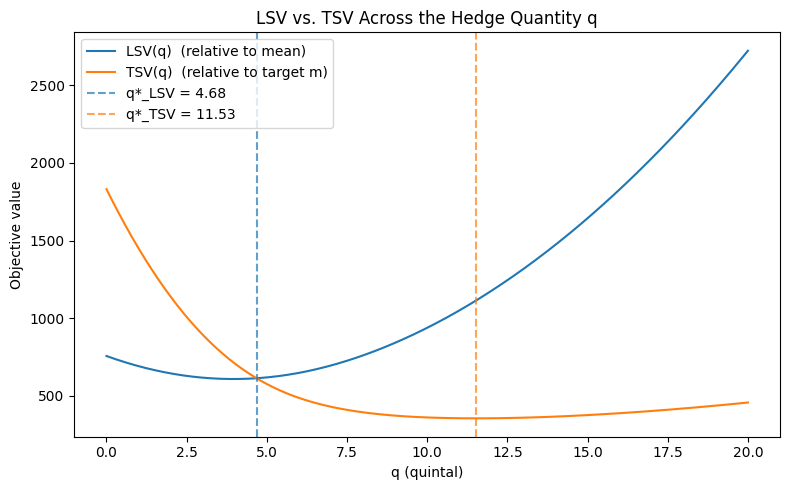

In [ ]:
q_grid = np.linspace(0, 20, 400)
lsv_grid = [LSV(qv) for qv in q_grid]
tsv_grid = [TSV(qv) for qv in q_grid]

plt.figure(figsize=(8, 5))
plt.plot(q_grid, lsv_grid, label="LSV(q)  (relative to mean)")
plt.plot(q_grid, tsv_grid, label="TSV(q)  (relative to target m)")
plt.axvline(q_LSV, color="tab:blue", linestyle="--", alpha=0.7, label=f"q*_LSV = {q_LSV:.2f}")
plt.axvline(q_TSV, color="tab:orange", linestyle="--", alpha=0.7, label=f"q*_TSV = {q_TSV:.2f}")
plt.axvline(q_Var, color="tab:green", linestyle=":", alpha=0.8, label=f"q*_Var = {q_Var:.2f}")
plt.xlabel("q (quintal)")
plt.ylabel("Objective value")
plt.title("LSV vs. TSV Across the Hedge Quantity q")
plt.legend()
plt.tight_layout()
plt.show()

## 8 Sensitivity to the target/required revenue $m$

LSV's objective never sees $m$ directly — $m$ only shows up through the constraint
$\mathbb{E}[W] \ge m$, so $q^*_{LSV}$ is **flat** in $m$ until the constraint starts to bind.
TSV's objective is built from $m$ itself, so $q^*_{TSV}$ should move **continuously** with $m$
even while the constraint is slack. We sweep $m$ and solve both models at each value to see
this.

Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point


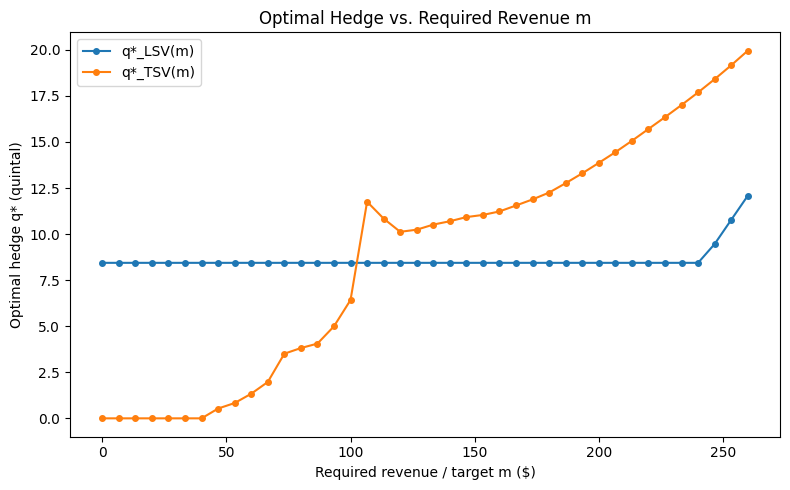

q*_LSV is constant while E[W] at the unconstrained LSV optimum already exceeds m;
q*_TSV keeps responding to m because m enters the TSV objective directly.


In [31]:
m_grid = np.linspace(0, 260, 40)
q_LSV_grid, q_TSV_grid = [], []

for m_val in m_grid:
    qL, _, _ = solve_LSV(P, Q, f, m_val)
    qT, _, _ = solve_TSV(P, Q, f, m_val)
    q_LSV_grid.append(qL)
    q_TSV_grid.append(qT)

plt.figure(figsize=(8, 5))
plt.plot(m_grid, q_LSV_grid, marker="o", ms=4, label="q*_LSV(m)")
plt.plot(m_grid, q_TSV_grid, marker="o", ms=4, label="q*_TSV(m)")
plt.xlabel("Required revenue / target m ($)")
plt.ylabel("Optimal hedge q* (quintal)")
plt.title("Optimal Hedge vs. Required Revenue m")
plt.legend()
plt.tight_layout()
plt.show()

print("q*_LSV is constant while E[W] at the unconstrained LSV optimum already exceeds m;")
print("q*_TSV keeps responding to m because m enters the TSV objective directly.")

## Note

When q is going down for the TSV, any value below the shown value is optimal, it is up to the solver to choose. Furthermore, these values are way too large

## 9. Downside risk of the resulting revenue distributions

Fix $m = 220$ again, take the two optimal hedges from Section 5, and compare the *realized*
revenue distributions: their shortfall probability, average shortfall size, and both risk
measures evaluated on each other's optimal hedge.

In [8]:
W_LSV = P * (Q - q_LSV) + f * q_LSV
W_TSV = P * (Q - q_TSV) + f * q_TSV

summary = pd.DataFrame({
    "q*":                [q_LSV, q_TSV],
    "E[W]":              [W_LSV.mean(), W_TSV.mean()],
    "Std[W]":             [W_LSV.std(), W_TSV.std()],
    "P(W < m)":           [(W_LSV < m).mean(), (W_TSV < m).mean()],
    "E[(m-W)_+]  (shortfall)": [np.maximum(m - W_LSV, 0).mean(), np.maximum(m - W_TSV, 0).mean()],
    "LSV(q*)":            [LSV(q_LSV), LSV(q_TSV)],
    "TSV(q*)":            [TSV(q_LSV), TSV(q_TSV)],
}, index=["LSV-optimal hedge", "TSV-optimal hedge"])

summary.round(3)

,q*,E[W],Std[W],P(W < m),E[(m-W)_+] (shortfall),LSV(q*),TSV(q*)
LSV-optimal hedge,8.440,241.466,40.256,0.290,7.167,775.854,301.289
TSV-optimal hedge,15.703,278.461,46.031,0.105,2.961,1183.572,152.995


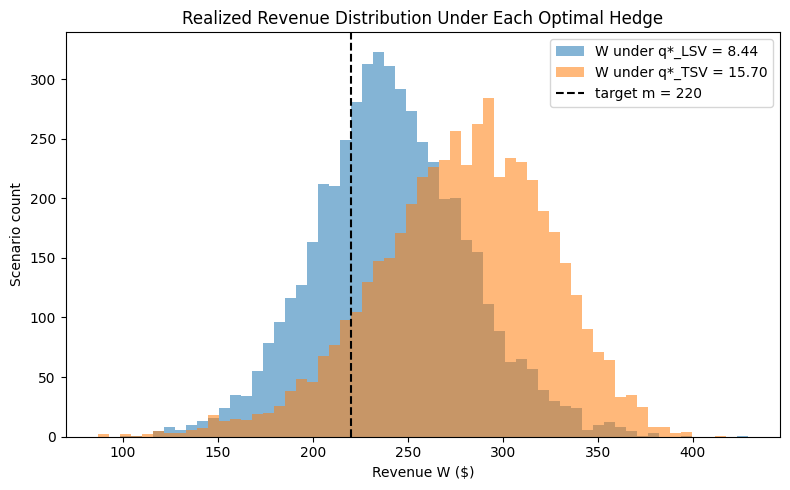

In [9]:
plt.figure(figsize=(8, 5))
bins = np.linspace(min(W_LSV.min(), W_TSV.min()), max(W_LSV.max(), W_TSV.max()), 60)
plt.hist(W_LSV, bins=bins, alpha=0.55, label=f"W under q*_LSV = {q_LSV:.2f}")
plt.hist(W_TSV, bins=bins, alpha=0.55, label=f"W under q*_TSV = {q_TSV:.2f}")
plt.axvline(m, color="black", linestyle="--", label=f"target m = {m:.0f}")
plt.xlabel("Revenue W ($)")
plt.ylabel("Scenario count")
plt.title("Realized Revenue Distribution Under Each Optimal Hedge")
plt.legend()
plt.tight_layout()
plt.show()

The TSV hedge is built to specifically shrink the mass and depth of outcomes *below $m$*,
so it typically shows a lower $P(W<m)$ and lower expected shortfall below $m$ than the LSV
hedge — at the cost of not minimizing dispersion around the (higher) sample mean. The LSV hedge
instead minimizes variability below whatever the mean revenue turns out to be, which need not
line up with the specific target $m$ the farmer actually cares about.

## 10. Sensitivity to yield risk and price-yield correlation

Finally, sweep $\sigma_Q$ and $\rho$ to see how the *gap* between $q^*_{LSV}$ and $q^*_{TSV}$
behaves as yield risk is switched on/off and as price-yield correlation strengthens.

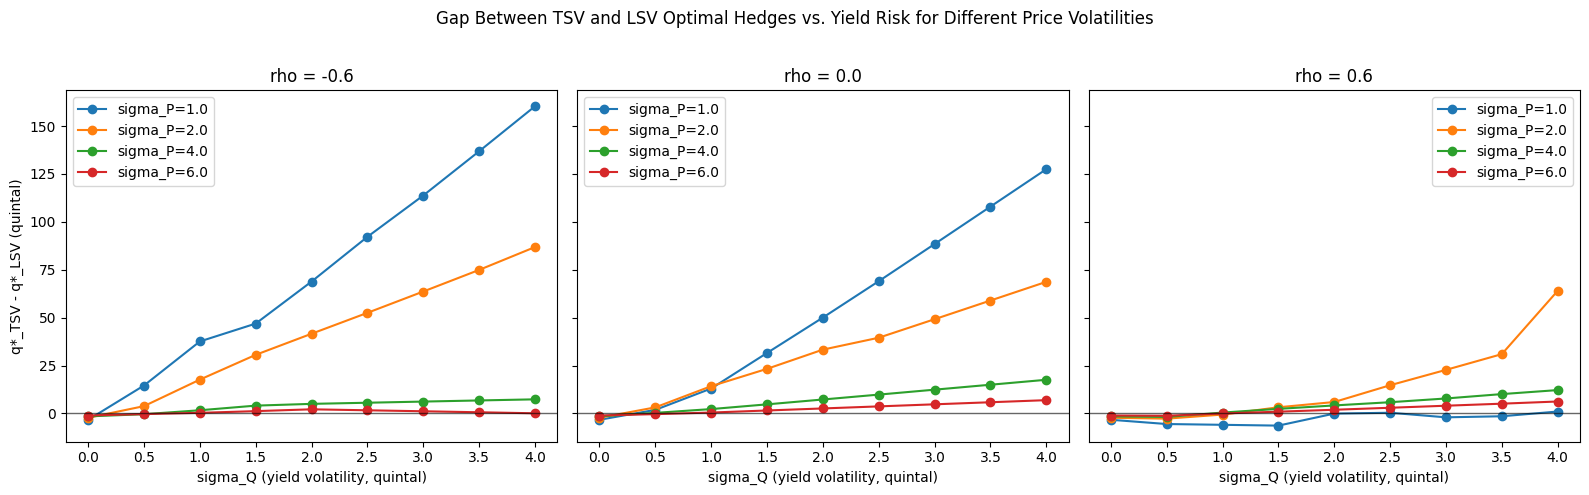

In [30]:
def make_data(sigma_P_val, sigma_Q_val, rho_val, N_=5000, seed=1):
    rng = np.random.RandomState(seed)
    cov_ = [[sigma_P_val**2, rho_val * sigma_P_val * sigma_Q_val],
            [rho_val * sigma_P_val * sigma_Q_val, sigma_Q_val**2]]
    PQ_ = rng.multivariate_normal([mu_P, mu_Q], cov_, size=N_)
    #print(f"there are {pd.isna(PQ_).sum()} NaN values in the generated data.")
    return PQ_[:, 0], PQ_[:, 1]

f = 25.0
m_fixed = 220.0
sigma_P_grid = [1.0, 2.0, 4.0, 6.0]
sigma_Q_grid = np.linspace(0.0, 4.0, 9)
rho_values = [-0.6, 0.0, 0.6]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, rho_val in zip(axes, rho_values):
    for sigma_P_val in sigma_P_grid:
        gaps = []
        for sQ in sigma_Q_grid:
            P_s, Q_s = make_data(sigma_P_val, sQ, rho_val)
            qL, _, _ = solve_LSV(P_s, Q_s, f, m_fixed)
            qT, _, _ = solve_TSV(P_s, Q_s, f, m_fixed)
            try:
                qL_val = float(qL)
                qT_val = float(qT)
            except (TypeError, ValueError):
                gaps.append(np.nan)
            else:
                if not np.isfinite(qL_val) or not np.isfinite(qT_val):
                    gaps.append(np.nan)
                else:
                    gaps.append(qT_val - qL_val)
        ax.plot(sigma_Q_grid, gaps, marker="o", label=f"sigma_P={sigma_P_val}")
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_xlabel("sigma_Q (yield volatility, quintal)")
    ax.set_title(f"rho = {rho_val}")
    ax.legend()
axes[0].set_ylabel("q*_TSV - q*_LSV (quintal)")
fig.suptitle("Gap Between TSV and LSV Optimal Hedges vs. Yield Risk for Different Price Volatilities")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 11. Remarks

- **Same solver pattern, different reference point.** Both LSV and TSV reduce to the identical
  `cvxpy` epigraph QP; only the affine term inside the hinge changes ($a_i,b_i$ built from the
  sample mean vs. $c_i,d_i$ built from the fixed target $m$).
- **LSV is locally "mean-seeking";** it does not know about $m$ except through the feasibility
  constraint, so its optimal hedge is *insensitive* to $m$ until the constraint binds
  (Section 8).
- **TSV is target-seeking;** it directly shapes the distribution to avoid falling short of $m$,
  so its optimal hedge responds smoothly to $m$ everywhere, and it produces a *smaller* shortfall
  probability and expected shortfall below $m$ than the LSV hedge (Section 9), which is exactly
  the risk it is designed to control.


                                   q*_LSV  q*_TSV    Opt LSV  Opt TSV  \
scenario                                                                
P=normal, Q=normal                 8.1605  1.6257   776.5118  16.7761   
P=uniform, Q=uniform               8.2355  4.7621   776.2050  24.7957   
P=normal, Q=uniform                8.3725  5.4021   775.8917  29.3250   
P=uniform, Q=normal                8.3903  0.0000   775.8742  18.7150   
P=deterministic, Q=normal         15.4357  0.0000  1155.0249  18.7150   
P=normal, Q=deterministic         10.0000  6.1913   795.9972  36.9770   
P=deterministic, Q=deterministic  12.9997  0.0000   941.4692  18.7150   

                                  TSV - LSV  
scenario                                     
P=normal, Q=normal                  -6.5348  
P=uniform, Q=uniform                -3.4734  
P=normal, Q=uniform                 -2.9704  
P=uniform, Q=normal                 -8.3903  
P=deterministic, Q=normal          -15.4357  
P=normal, Q=determin

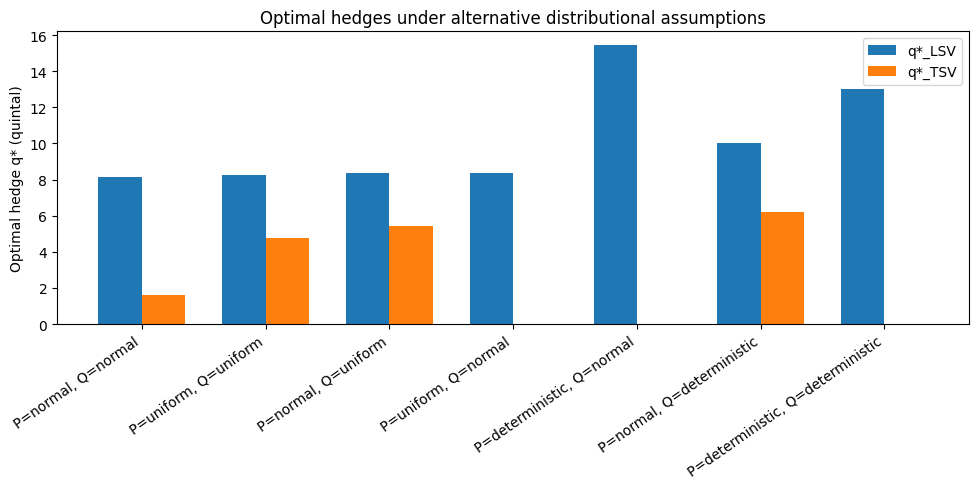

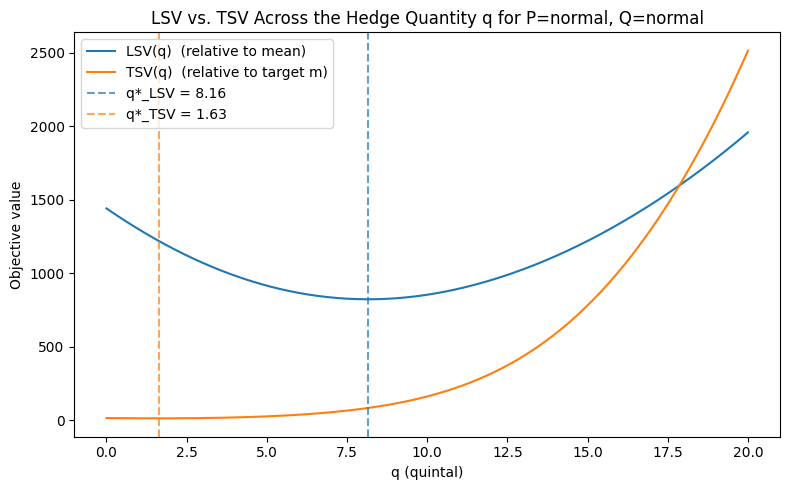

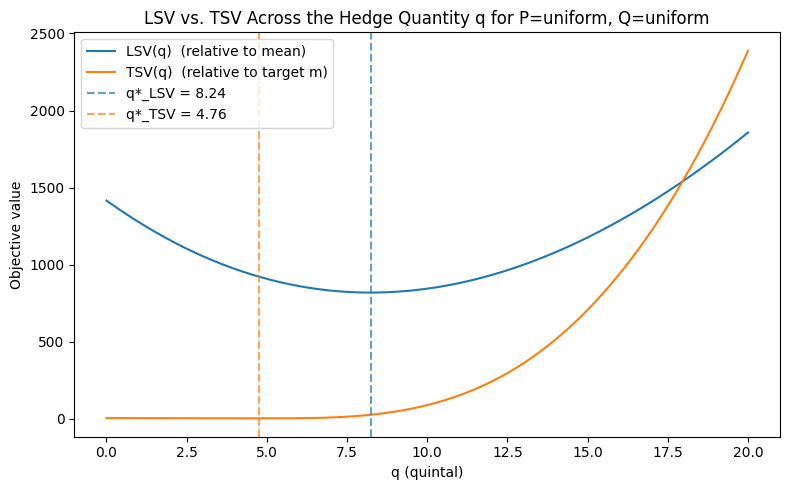

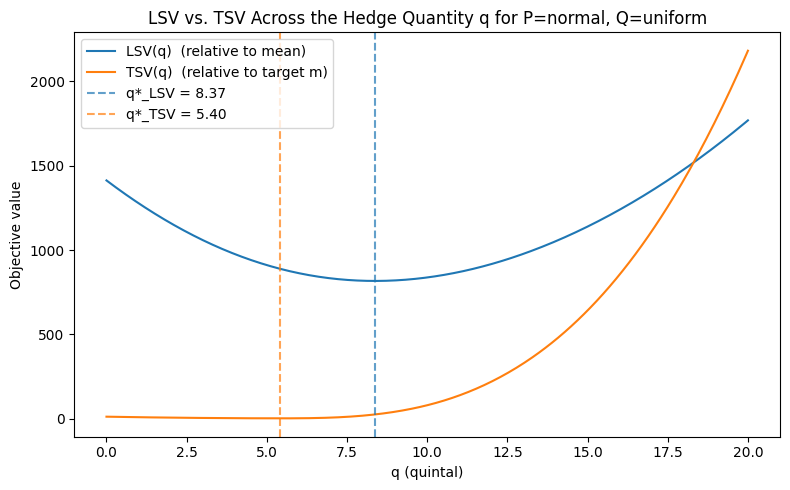

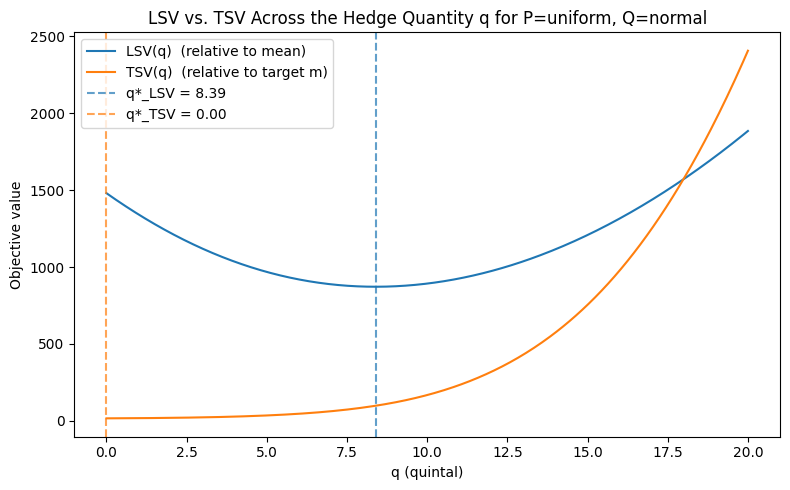

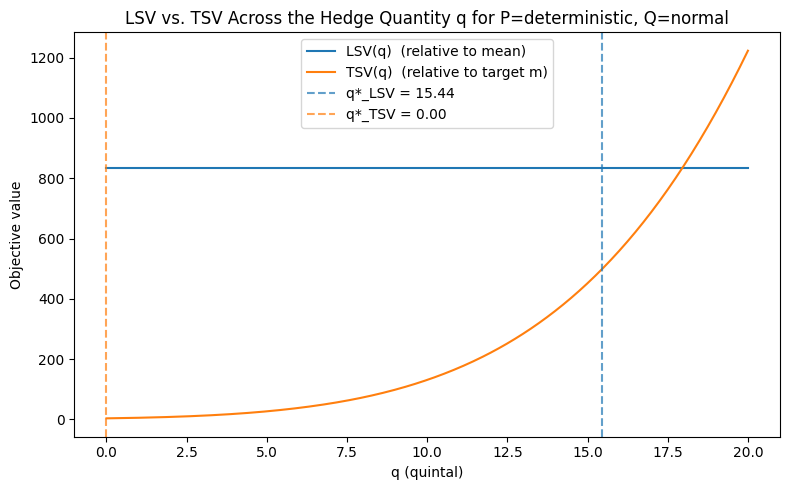

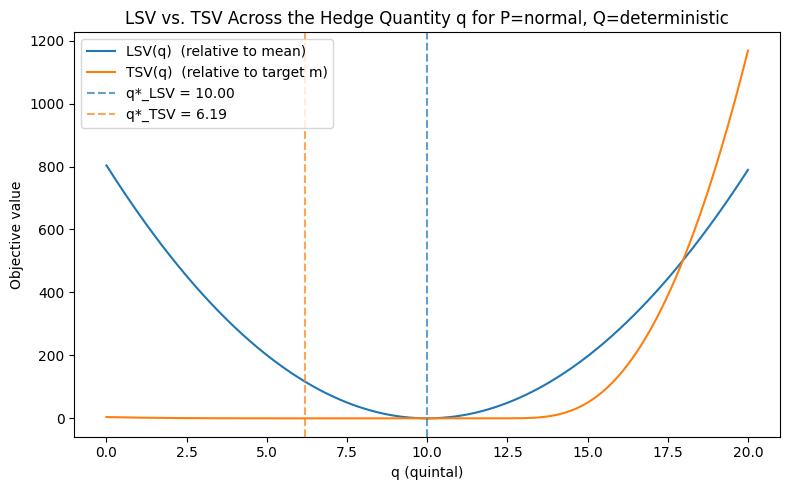

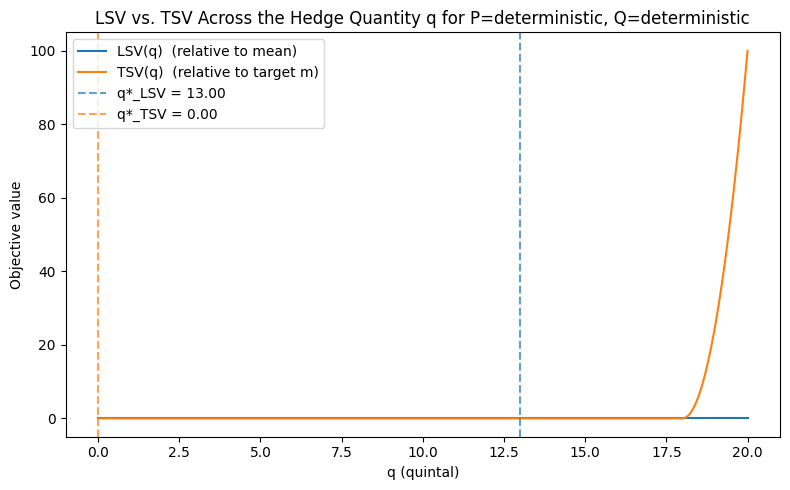

In [11]:
# 8. Alternative distributional assumptions: uniform and deterministic variants

def make_data(kind_P, kind_Q, N=N, seed=123):
    rng = np.random.RandomState(seed)

    def sample(kind, mu, sigma):
        if kind == "normal":
            return rng.normal(mu, sigma, size=N)
        if kind == "uniform":
            half_span = np.sqrt(3) * sigma
            return rng.uniform(mu - half_span, mu + half_span, size=N)
        if kind == "deterministic":
            return np.full(N, mu)
        raise ValueError(f"Unknown distribution kind: {kind}")

    return sample(kind_P, mu_P, sigma_P), sample(kind_Q, mu_Q, sigma_Q)

distribution_cases = [
    ("normal", "normal"),
    ("uniform", "uniform"),
    ("normal", "uniform"),
    ("uniform", "normal"),
    ("deterministic", "normal"),
    ("normal", "deterministic"),
    ("deterministic", "deterministic"),
]
m = 110
f = 15

rows = []
for i, (kind_P, kind_Q) in enumerate(distribution_cases):
    P_sim, Q_sim = make_data(kind_P, kind_Q, seed=100 + i)
    qL, _, _ = solve_LSV(P_sim, Q_sim, f, m)
    qT, _, _ = solve_TSV(P_sim, Q_sim, f, m)
    rows.append({
        "scenario": f"P={kind_P}, Q={kind_Q}",
        "q*_LSV": qL,
        "q*_TSV": qT,
        "Opt LSV": LSV(qL),
        "Opt TSV": TSV(qT), 
        "TSV - LSV": qT - qL,
    })

dist_results = pd.DataFrame(rows).set_index("scenario")
print(dist_results.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dist_results))
width = 0.35

ax.bar(x - width / 2, dist_results["q*_LSV"], width, label="q*_LSV")
ax.bar(x + width / 2, dist_results["q*_TSV"], width, label="q*_TSV")

ax.set_xticks(x)
ax.set_xticklabels(dist_results.index, rotation=35, ha="right")
ax.set_ylabel("Optimal hedge q* (quintal)")
ax.set_title("Optimal hedges under alternative distributional assumptions")
ax.legend()
plt.tight_layout()
plt.show()

for idx, (kind_P, kind_Q) in enumerate(distribution_cases):
    P_sim, Q_sim = make_data(kind_P, kind_Q, seed=100 + idx)
    qL, _, _ = solve_LSV(P_sim, Q_sim, f, m)
    qT, _, _ = solve_TSV(P_sim, Q_sim, f, m)

    Pbar_sim = P_sim.mean()
    PQbar_sim = (P_sim * Q_sim).mean()
    a = PQbar_sim - P_sim * Q_sim
    b = Pbar_sim - P_sim
    c = m - P_sim * Q_sim
    d = f - P_sim

    q_grid = np.linspace(0, 20, 400)
    lsv_grid_sim = [np.mean(np.maximum(a - b * qv, 0) ** 2) for qv in q_grid]
    tsv_grid_sim = [np.mean(np.maximum(c - d * qv, 0) ** 2) for qv in q_grid]

    plt.figure(figsize=(8, 5))
    plt.plot(q_grid, lsv_grid_sim, label="LSV(q)  (relative to mean)")
    plt.plot(q_grid, tsv_grid_sim, label="TSV(q)  (relative to target m)")
    plt.axvline(qL, color="tab:blue", linestyle="--", alpha=0.7, label=f"q*_LSV = {qL:.2f}")
    plt.axvline(qT, color="tab:orange", linestyle="--", alpha=0.7, label=f"q*_TSV = {qT:.2f}")
    plt.xlabel("q (quintal)")
    plt.ylabel("Objective value")
    plt.title(f"LSV vs. TSV Across the Hedge Quantity q for P={kind_P}, Q={kind_Q}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Remarks from different distribution
For normal and uniform distributions, the TSV prefers larger values for q when 

C:\Users\User\AppData\Local\Temp\ipykernel_33264\2300779112.py:54: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(cp.OSQP, verbose=verbose)


Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point


C:\Users\User\AppData\Local\Temp\ipykernel_33264\2300779112.py:35: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(cp.CLARABEL)


Polishing not needed - no active set detected at optimal point


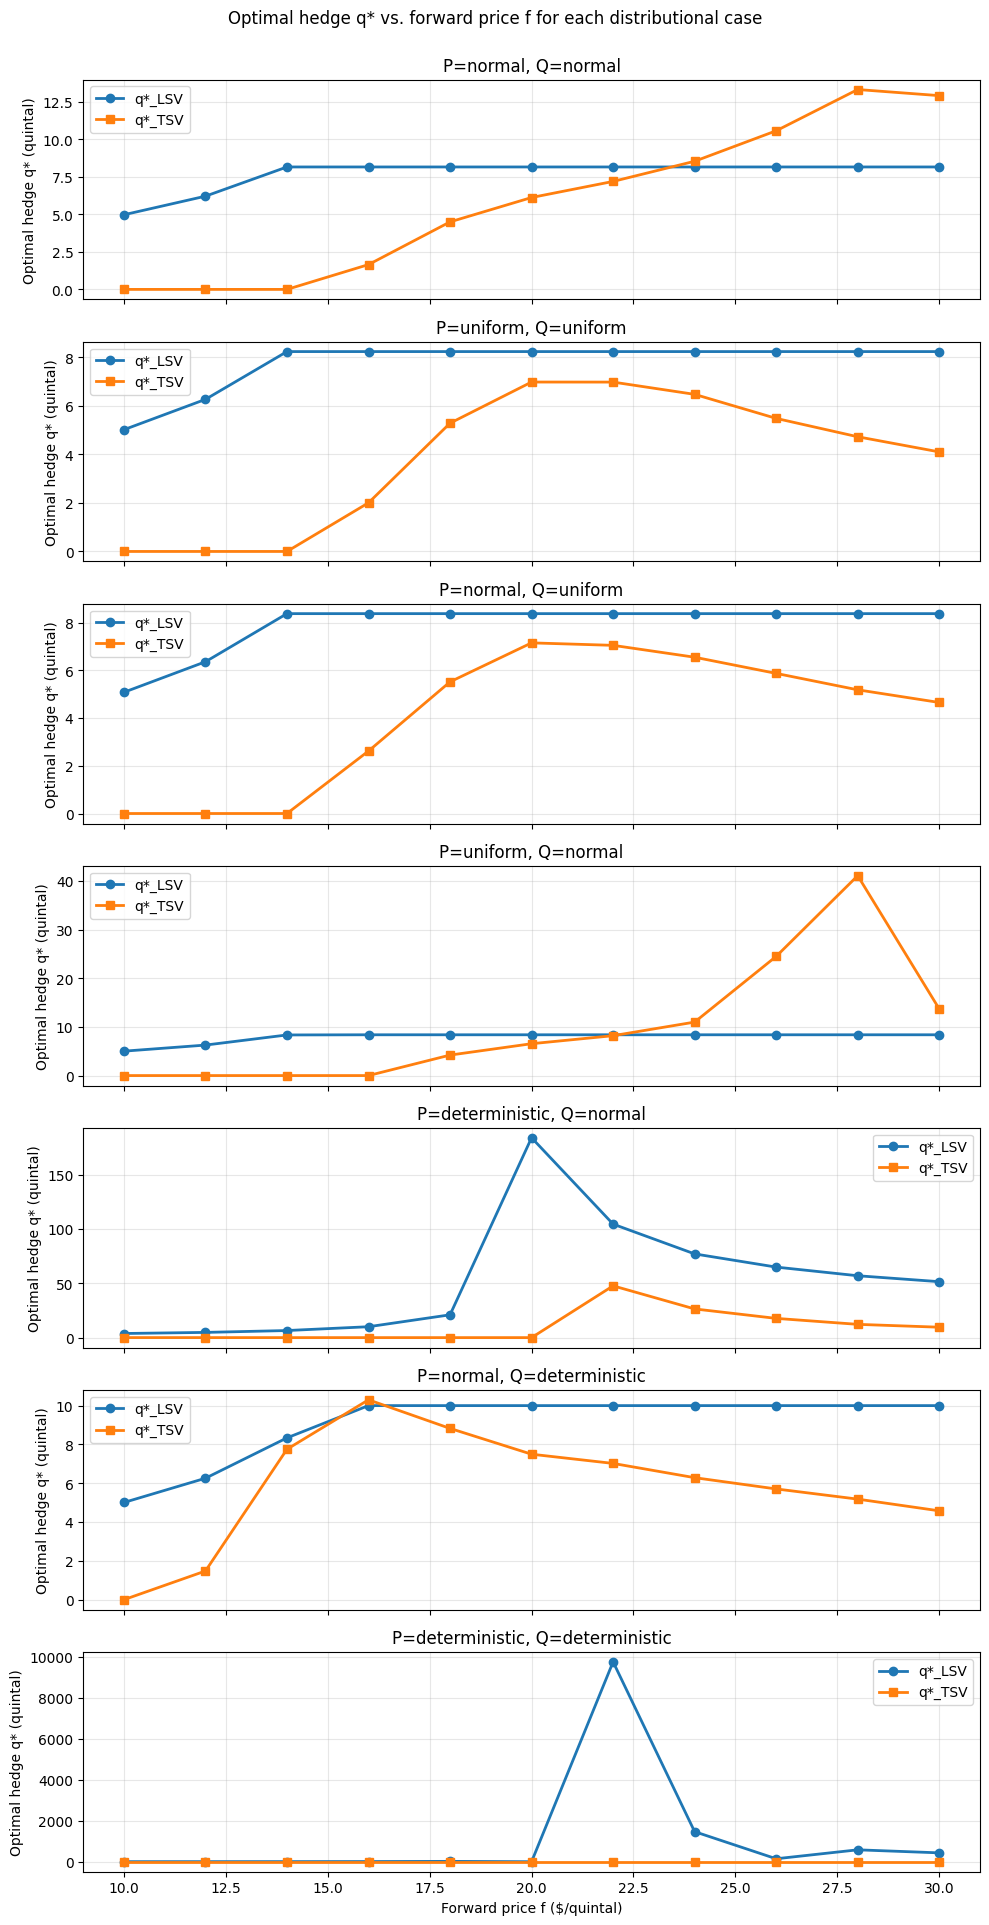

                            scenario     f     q*_LSV  q*_TSV
0                 P=normal, Q=normal  10.0     4.9747  0.0000
1                 P=normal, Q=normal  12.0     6.2130  0.0000
2                 P=normal, Q=normal  14.0     8.1605  0.0000
3                 P=normal, Q=normal  16.0     8.1605  1.6539
4                 P=normal, Q=normal  18.0     8.1605  4.4997
..                               ...   ...        ...     ...
72  P=deterministic, Q=deterministic  22.0  9766.5205  0.0000
73  P=deterministic, Q=deterministic  24.0  1468.5237  0.0000
74  P=deterministic, Q=deterministic  26.0   145.0440  0.0000
75  P=deterministic, Q=deterministic  28.0   581.6603  0.0000
76  P=deterministic, Q=deterministic  30.0   433.6853  0.0000

[77 rows x 4 columns]


In [23]:
# Sweep the forward price f over +/-50% of E[P] for each distributional case
f_grid = np.linspace(0.5 * mu_P, 1.5 * mu_P, 11)
m = 150 #### This value matters a lot for the TSV solution, but not for the LSV solution, which is only dependent on m in the constraint.

rows = []

fig, axes = plt.subplots(len(distribution_cases), 1, figsize=(10, 2.8 * len(distribution_cases)), sharex=True)
if len(distribution_cases) == 1:
    axes = [axes]

for ax, (idx, (kind_P, kind_Q)) in zip(axes, enumerate(distribution_cases)):
    P_sim, Q_sim = make_data(kind_P, kind_Q, seed=100 + idx)

    q_lsv_vals = []
    q_tsv_vals = []

    for f_val in f_grid:
        qL, _, _ = solve_LSV(P_sim, Q_sim, f_val, m)
        qT, _, _ = solve_TSV(P_sim, Q_sim, f_val, m)
        q_lsv_vals.append(qL)
        q_tsv_vals.append(qT)

        rows.append({
            "scenario": f"P={kind_P}, Q={kind_Q}",
            "f": f_val,
            "q*_LSV": qL,
            "q*_TSV": qT,
            #"TSV - LSV": qT - qL,
        })

    q_lsv_vals = np.array(q_lsv_vals)
    q_tsv_vals = np.array(q_tsv_vals)

    ax.plot(f_grid, q_lsv_vals, marker="o", linewidth=2, label="q*_LSV")
    ax.plot(f_grid, q_tsv_vals, marker="s", linewidth=2, label="q*_TSV")
    ax.set_title(f"P={kind_P}, Q={kind_Q}")
    ax.set_ylabel("Optimal hedge q* (quintal)")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Forward price f ($/quintal)")
fig.suptitle("Optimal hedge q* vs. forward price f for each distributional case")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

results_df = pd.DataFrame(rows)
print(results_df.round(4))